# Код для создания валидационного датасета
~ 600 примеров
3 сценария:
- Поиск изображением по изображениям
- Поиск текстом по изображениям
- Мультимодальный поиск: картинка + уточняющий текстовый запрос



## 1. Импорт библиотек

- pandas для работы с данными
- matplotlib & Image для визуализации и работы с изображениями
- train_test_split для создания подвыборки

In [41]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import base64
import requests
import random
import math
import os
import time


In [2]:
ITEMS_PATH = 'dataset_1M/items.csv'
IMAGES_PATH = 'dataset_1M/images.csv'
ITEM_FEATURES = ['param2', 'category_name', 'cvet', 'brand']
SEED = 42

In [3]:
items = pd.read_csv(ITEMS_PATH)
images = pd.read_csv(IMAGES_PATH)

Распределение айтемов по категориям

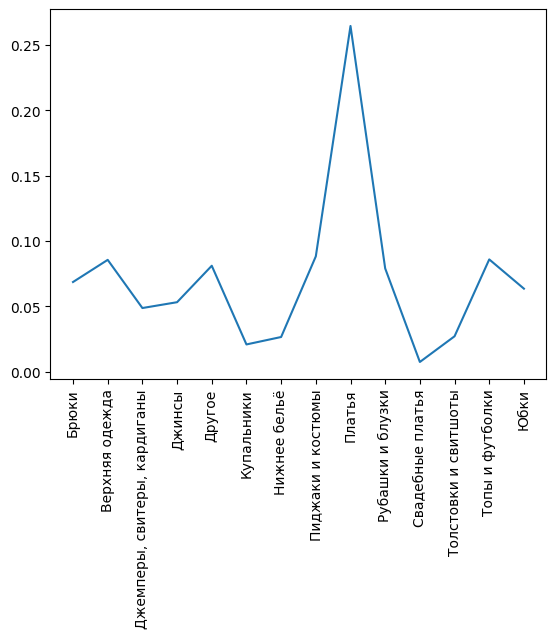

In [34]:
plt.plot(items.groupby('param2').size() / len(items))
plt.xticks(rotation=90)
print()

In [40]:
distribution = items.groupby('param2').size()
distribution / sum(distribution)

param2
Брюки                           0.068595
Верхняя одежда                  0.085557
Джемперы, свитеры, кардиганы    0.048677
Джинсы                          0.053143
Другое                          0.081044
Купальники                      0.020805
Нижнее бельё                    0.026500
Пиджаки и костюмы               0.088243
Платья                          0.264593
Рубашки и блузки                0.079001
Свадебные платья                0.007381
Толстовки и свитшоты            0.027051
Топы и футболки                 0.085904
Юбки                            0.063508
dtype: float64

In [4]:
def show_all_images_of_item(images: pd.DataFrame, item_id: int, title: str = '') -> None:
    images_of_item = images[images['item_id'] == item_id]
    images_paths = images_of_item['image_path'].values
    num_of_images = len(images_of_item)

    n_cols = min(3, num_of_images)
    n_rows = math.ceil(num_of_images / 3)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
    if n_rows == 1 and n_cols == 1:
        axs = [[axs]]
    elif n_rows == 1:
        axs = [axs]
    elif n_cols == 1:
        axs = [[ax] for ax in axs]

    for row in range(n_rows):
        for col in range(n_cols):
            idx = row * 3 + col
            ax = axs[row][col]
            if idx < num_of_images:
                img = Image.open(os.path.join('dataset_1M', images_paths[idx]))
                ax.imshow(img)
            ax.axis('off')

    if title:
        fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

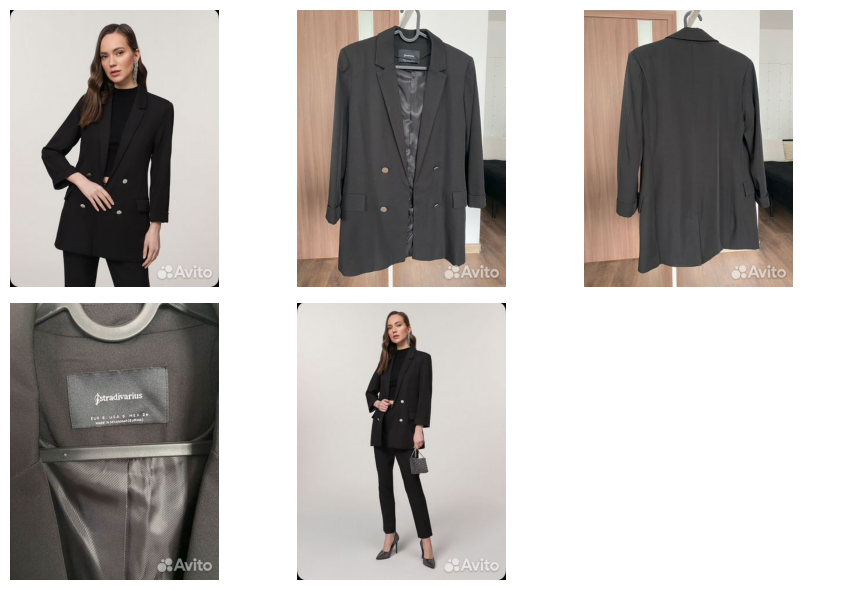

In [5]:
show_all_images_of_item(images, item_id=365182752803)

Создание датасетов для 3 отдельных сценариев: vis, txt, mm

выборка сбалансирована, на этапе валидации можно посчитать метрики micro, macro(weighted)

In [6]:
items_for_val = items.groupby('param2', group_keys=False).apply(lambda x: x.sample(n=43, random_state=SEED, replace=True))
vis_val, txt_and_multimodal_val = train_test_split(items_for_val, test_size=0.66, stratify=items_for_val['param2'], random_state=SEED)
txt_val, multimodal_val = train_test_split(txt_and_multimodal_val, test_size=0.5, stratify=txt_and_multimodal_val['param2'], random_state=SEED)

C:\Users\user\AppData\Local\Temp\ipykernel_10156\822208044.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  items_for_val = items.groupby('param2', group_keys=False).apply(lambda x: x.sample(n=43, random_state=SEED, replace=True))


## 2. Создание val_vision_dataset

- Для каждого айтема query изображение выбирается рандомно из его изображений
- Вручную отсматриваются айтема такого же цвета, категории, бренда чтобы если нужно включить в таргеты



In [7]:
VAL_CSV_PATH = 'val_dataset_vis.csv'

val_columns = [
    'query_id', 'mode', 'item_id', 'image_id', 'image_path',
    'txt_query', 'target_images_id',
    'param2', 'category_name', 'sostoyanie', 'cvet', 'brand',
]

vis_val_reset = vis_val.reset_index(drop=True)

if os.path.exists(VAL_CSV_PATH):
    existing = pd.read_csv(VAL_CSV_PATH)
    start_idx = len(existing)
    print(f'Loaded {start_idx} rows from {VAL_CSV_PATH}, resuming from index {start_idx}')
else:
    pd.DataFrame(columns=val_columns).to_csv(VAL_CSV_PATH, index=False)
    start_idx = 0
    print(f'Created new {VAL_CSV_PATH}')

Loaded 204 rows from val_dataset_vis.csv, resuming from index 204


In [ ]:
for idx in range(start_idx, len(vis_val_reset)):
    row = vis_val_reset.iloc[idx]
    cur_item_id = row['item_id']
    param2 = row['param2']
    category_name = row['category_name']
    brand = row['brand']
    sostoyanie = row['sostoyanie']
    cvet = row['cvet']

    item_images = images[images['item_id'] == cur_item_id]
    image_ids = list(item_images['image_id'])

    if len(image_ids) == 0:
        print(f'[{idx}] No images for item {cur_item_id}, skipping')
        continue

    query_image_id = random.choice(image_ids)
    target_image_ids = [iid for iid in image_ids if iid != query_image_id]
    query_image_path = item_images[item_images['image_id'] == query_image_id]['image_path'].values[0]

    close_items = items[
        (items['param2'] == param2) &
        (items['category_name'] == category_name) &
        (items['brand'] == brand) &
        (items['cvet'] == cvet) &
        (items['item_id'] != cur_item_id)
    ]


    if not close_items.empty and len(close_items) < 30:
        print(f'[{idx + 1}/{len(vis_val_reset)}] Query item: {cur_item_id}')
        print(f'param2={param2}, cvet={cvet}, brand={brand}')
        show_all_images_of_item(images, item_id=cur_item_id,
                                title=f'QUERY: {cur_item_id}')
        close_items_reset = close_items.reset_index(drop=True)
        print(f'Found {len(close_items_reset)} similar items:')
        for i, (_, c_row) in enumerate(close_items_reset.iterrows()):
            show_all_images_of_item(images, item_id=c_row['item_id'],
                                    title=f'[{i}] Candidate: {c_row["item_id"]}')

        wait_sec = 5 * len(close_items_reset)
        print(f'Waiting {wait_sec}s for review...')
        time.sleep(wait_sec)

        answer = input(
            f'Enter {len(close_items_reset)} digits (1=add, 0=skip), e.g. "{"1"*len(close_items_reset)}": '
        ).strip()

        for i, digit in enumerate(answer):
            if i < len(close_items_reset) and digit == '1':
                c_id = close_items_reset.iloc[i]['item_id']
                c_image_ids = list(images[images['item_id'] == c_id]['image_id'])
                target_image_ids.extend(c_image_ids)
    else:
        print('No similar items found/ too much similar items')

    new_row = pd.DataFrame([{
        'query_id': idx,
        'mode': 'image',
        'item_id': cur_item_id,
        'image_id': query_image_id,
        'image_path': query_image_path,
        'txt_query': None,
        'target_images_id': ';'.join(map(str, target_image_ids)),
        'param2': param2,
        'category_name': category_name,
        'sostoyanie': sostoyanie,
        'cvet': cvet,
        'brand': brand,
    }])
    new_row.to_csv(VAL_CSV_PATH, mode='a', header=False, index=False)
    print(f'Saved. Total targets: {len(target_image_ids)} images')

In [36]:
val_ds = pd.read_csv('val_dataset_vis.csv')
val_ds = val_ds[~val_ds['target_images_id'].isna()]
val_ds['query_id'] = range(len(val_ds))
val_ds.to_csv('val_dataset_vis.csv', index=False)

In [29]:
val_ds['query_id'] = range(len(val_ds))

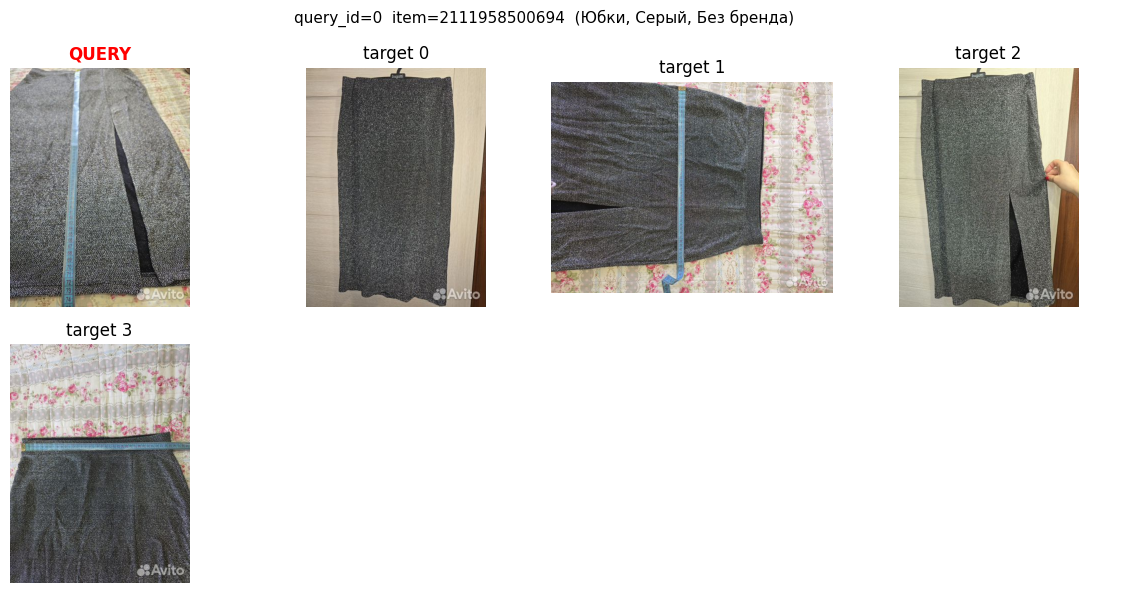

In [40]:
def show_query_and_targets(val_csv_path: str, query_idx: int) -> None:
    val_ds = pd.read_csv(val_csv_path)
    row = val_ds.iloc[query_idx]

    query_path = os.path.join('dataset_1M', row['image_path'])
    target_ids = str(row['target_images_id']).split(';') if pd.notna(row['target_images_id']) else []
    target_paths = [
        os.path.join('dataset_1M', images[images['image_id'] == int(tid)]['image_path'].values[0])
        for tid in target_ids if tid
    ]

    n = 1 + len(target_paths)
    n_cols = min(4, n)
    n_rows = math.ceil(n / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
    axs = [axs] if n_rows == 1 else axs
    if n_cols == 1:
        axs = [[ax] for ax in axs]

    for i in range(n_rows * n_cols):
        r, c = divmod(i, n_cols)
        ax = axs[r][c]
        if i == 0:
            ax.imshow(Image.open(query_path))
            ax.set_title('QUERY', color='red', fontweight='bold')
        elif i - 1 < len(target_paths):
            ax.imshow(Image.open(target_paths[i - 1]))
            ax.set_title(f'target {i - 1}')
        ax.axis('off')

    fig.suptitle(f'query_id={int(row["query_id"])}  item={row["item_id"]}  ({row["param2"]}, {row["cvet"]}, {row["brand"]})', fontsize=11)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

show_query_and_targets(VAL_CSV_PATH, query_idx=0)

## 3. Создание датасета для поиска текстом
- Для создания используется VLM модель gpt-4o
- Ей на вход подается картинка с товаром и метаданные по товару, она призвана придумать короткий текстовый запрос соответствующий этому товару

In [47]:
OPENROUTER_API_KEY = os.environ["OPENROUTER_API_KEY"]
VLM_MODEL = 'openai/gpt-4o'
TXT_VAL_CSV_PATH = 'val_dataset_txt.csv'

txt_val_reset = txt_val.reset_index(drop=True)

if os.path.exists(TXT_VAL_CSV_PATH):
    existing_txt = pd.read_csv(TXT_VAL_CSV_PATH)
    txt_start_idx = len(existing_txt)
else:
    pd.DataFrame(columns=val_columns).to_csv(TXT_VAL_CSV_PATH, index=False)
    txt_start_idx = 0


def image_to_base64(path: str) -> str:
    with open(path, 'rb') as f:
        return base64.b64encode(f.read()).decode()


def generate_txt_query(image_path: str, param2: str, cvet: str, brand: str) -> str:
    b64 = image_to_base64(image_path)

    resp = requests.post(
        'https://openrouter.ai/api/v1/chat/completions',
        headers={
            'Authorization': f'Bearer {OPENROUTER_API_KEY}',
            'Content-Type': 'application/json',
        },
        json={
            'model': VLM_MODEL,
            'messages': [
                {
                    'role': 'user',
                    'content': [
                        {
                            'type': 'image_url',
                            'image_url': {
                                'url': f'data:image/jpeg;base64,{b64}',
                            },
                        },
                        {
                            'type': 'text',
                            'text': (
                                'Ты — помощник для генерации поисковых запросов на маркетплейсе одежды. '
                                'Посмотри на изображение товара. '
                                f'Характеристики: тип — {param2}, цвет — {cvet}, бренд — {brand}. '
                                'Напиши короткий текстовый поисковый запрос на русском языке, '
                                'который пользователь ввёл бы чтобы найти именно этот товар. '
                                'Ответь ТОЛЬКО текстом запроса, без кавычек и пояснений.'
                            ),
                        },
                    ],
                }
            ],
            'max_tokens': 100,
        },
    )
    resp.raise_for_status()
    return resp.json()['choices'][0]['message']['content'].strip()

In [48]:
for idx in range(txt_start_idx, len(txt_val_reset)):
    row = txt_val_reset.iloc[idx]
    cur_item_id = row['item_id']

    title_img = images[(images['item_id'] == cur_item_id) & (images['is_title'] == True)]
    if title_img.empty:
        title_img = images[images['item_id'] == cur_item_id].iloc[:1]
    if title_img.empty:
        print(f'[{idx}] No images for {cur_item_id}, skipping')
        continue

    title_image_path = os.path.join('dataset_1M', title_img['image_path'].values[0])
    title_image_id = title_img['image_id'].values[0]

    all_image_ids = list(images[images['item_id'] == cur_item_id]['image_id'])

    try:
        txt_query = generate_txt_query(
            title_image_path,
            param2=row['param2'],
            cvet=row['cvet'],
            brand=row['brand'],
        )
    except Exception as e:
        print(f'[{idx}] Error for {cur_item_id}: {e}')
        time.sleep(5)
        continue

    new_row = pd.DataFrame([{
        'query_id': idx,
        'mode': 'txt',
        'item_id': cur_item_id,
        'image_id': title_image_id,
        'image_path': title_img['image_path'].values[0],
        'txt_query': txt_query,
        'target_images_id': ';'.join(map(str, all_image_ids)),
        'param2': row['param2'],
        'category_name': row['category_name'],
        'sostoyanie': row['sostoyanie'],
        'cvet': row['cvet'],
        'brand': row['brand'],
    }])
    new_row.to_csv(TXT_VAL_CSV_PATH, mode='a', header=False, index=False)

    if (idx + 1) % 10 == 0:
        print(f'[{idx + 1}/{len(txt_val_reset)}] "{txt_query}"')

[10/199] "чёрные широкие брюки Ushatava"
[20/199] "белая рубашка в полоску Incity"
[30/199] "тельняшка в полоску с надписью"
[40/199] "бордовое нижнее белье Kenzo с цветочным принтом"
[50/199] "футболка с принтом женская стильная"
[60/199] "белый джемпер с рисунком"
[70/199] "розовая футболка с принтом женская"
[80/199] "топ чёрный с коротким рукавом"
[90/199] "коричневый клетчатый женский костюм"
[100/199] "серый свитшот с кружевом Kiabi"
[110/199] "свадебное платье с длинным рукавом белое"
[120/199] "бежевый джемпер H&M с пуговицами"
[130/199] "купальник с длинным рукавом черный вырез спина"
[140/199] "платье коричневое безрукавное миди женское"
[150/199] "брюки шорты клетка серые Befree"
[160/199] "черная футболка и серые джинсы комплект"
[170/199] "синий цветочный купальник без бренда"
[180/199] "одежда секонд-хенд разноцветная без бренда"
[190/199] "синие джинсовые шорты Zara"


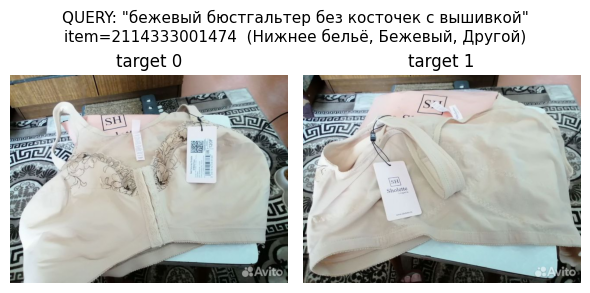

In [57]:
def show_txt_query_and_targets(txt_csv_path: str, query_idx: int) -> None:
    df = pd.read_csv(txt_csv_path)
    row = df.iloc[query_idx]

    target_ids = str(row['target_images_id']).split(';') if pd.notna(row['target_images_id']) else []
    target_paths = [
        os.path.join('dataset_1M', images[images['image_id'] == int(tid)]['image_path'].values[0])
        for tid in target_ids if tid
    ]

    n = len(target_paths)
    n_cols = min(4, max(n, 1))
    n_rows = math.ceil(n / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
    if n_rows == 1 and n_cols == 1:
        axs = [[axs]]
    elif n_rows == 1:
        axs = [axs]
    elif n_cols == 1:
        axs = [[ax] for ax in axs]

    for i in range(n_rows * n_cols):
        r, c = divmod(i, n_cols)
        ax = axs[r][c]
        if i < n:
            ax.imshow(Image.open(target_paths[i]))
            ax.set_title(f'target {i}')
        ax.axis('off')

    fig.suptitle(
        f'QUERY: "{row["txt_query"]}"\n'
        f'item={row["item_id"]}  ({row["param2"]}, {row["cvet"]}, {row["brand"]})',
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()
    plt.close(fig)


show_txt_query_and_targets(TXT_VAL_CSV_PATH, query_idx=190)

## 4. Создание датасета для multimodal поиска
- Здесь также используется VLM модель
- Ей подается 2 товара, она должна дать текстовый запрос чтобы прийти от первого товара + текстового запроса к второму товару. Если такой запрос сложно/невозможно составить, то пробуем с другими товарами

In [58]:
MULTI_VAL_CSV_PATH = 'val_dataset_multimodal.csv'
TARGET_COUNT = 200
MAX_ATTEMPTS = 800

MULTI_VLM_MODEL = 'openai/gpt-4o'

multimodal_val_reset = multimodal_val.reset_index(drop=True)

if os.path.exists(MULTI_VAL_CSV_PATH):
    existing_multi = pd.read_csv(MULTI_VAL_CSV_PATH)
    multi_start = len(existing_multi)
    print(f'Resuming from {multi_start}')
else:
    pd.DataFrame(columns=val_columns).to_csv(MULTI_VAL_CSV_PATH, index=False)
    multi_start = 0
    print(f'Created {MULTI_VAL_CSV_PATH}')


def get_title_image_path(item_id: int) -> str | None:
    title_img = images[(images['item_id'] == item_id) & (images['is_title'] == True)]
    if title_img.empty:
        title_img = images[images['item_id'] == item_id].head(1)
    if title_img.empty:
        return None
    return title_img['image_path'].values[0]


MULTIMODAL_SYSTEM_PROMPT = (
    'Ты имитируешь поведение реального пользователя маркетплейса одежды (Avito). '
    'На сайте есть функция: загрузить фото вещи как референс и дописать текст в поисковую строку, '
    'чтобы уточнить чем искомая вещь отличается от референса.\n\n'
    'Твоя задача: получив два изображения одежды одной категории, написать текст '
    'который пользователь вбил бы в строку поиска, имея первое изображение как референс '
    'и желая найти вещь со второго изображения.'
)

MULTIMODAL_USER_PROMPT = (
    'Референс (загруженное пользователем фото):\n[первое изображение]\n\n'
    'Целевой товар (то что пользователь хочет найти):\n[второе изображение]\n\n'
    'Правила:\n'
    '1. Опиши ТОЛЬКО отличия целевого товара от референса. Пользователь уже загрузил '
    'референс — система видит его, повторять не нужно.\n'
    '2. Обращай внимание на ВСЕ визуальные различия:\n'
    '   - цвет и оттенок ("в синем", "потемнее")\n'
    '   - принт и узор ("в полоску", "однотонное", "в горох")\n'
    '   - длина ("покороче", "макси", "до колена")\n'
    '   - рукава ("без рукавов", "длинный рукав", "с фонариками")\n'
    '   - крой и силуэт ("оверсайз", "приталенное", "расклешённое")\n'
    '   - материал ("из джинсы", "кожаное", "вязаное")\n'
    '   - детали ("с карманами", "на молнии", "с поясом", "с кружевом")\n'
    '   - вырез ("с V-вырезом", "водолазка", "на бретельках")\n'
    '3. Пиши как реальный человек в поисковой строке:\n'
    '   - коротко, 2-7 слов\n'
    '   - без заглавных букв и точек в конце\n'
    '   - можно неформально: "покороче", "потемнее", "синее"\n'
    '   - НЕ пиши литературным языком и НЕ используй сложные обороты\n'
    '4. НЕ упоминай слова "фото", "изображение", "картинка", номера.\n'
    '5. НЕ начинай с "похожее/такое же" если дальше нет конкретного отличия.\n\n'
    'Если вещи визуально почти идентичны или различия неуловимы — ответь: no\n\n'
    'Ответь ТОЛЬКО текстом запроса (или no), ничего больше.'
)


def generate_multimodal_query(src_path: str, tgt_path: str) -> str | None:
    b64_src = image_to_base64(src_path)
    b64_tgt = image_to_base64(tgt_path)

    resp = requests.post(
        'https://openrouter.ai/api/v1/chat/completions',
        headers={
            'Authorization': f'Bearer {OPENROUTER_API_KEY}',
            'Content-Type': 'application/json',
        },
        json={
            'model': MULTI_VLM_MODEL,
            'messages': [
                {
                    'role': 'system',
                    'content': MULTIMODAL_SYSTEM_PROMPT,
                },
                {
                    'role': 'user',
                    'content': [
                        {
                            'type': 'image_url',
                            'image_url': {'url': f'data:image/jpeg;base64,{b64_src}'},
                        },
                        {
                            'type': 'image_url',
                            'image_url': {'url': f'data:image/jpeg;base64,{b64_tgt}'},
                        },
                        {
                            'type': 'text',
                            'text': MULTIMODAL_USER_PROMPT,
                        },
                    ],
                },
            ],
            'max_tokens': 40,
            'temperature': 0.9,
        },
    )
    resp.raise_for_status()
    answer = resp.json()['choices'][0]['message']['content'].strip().strip('"\'')
    if answer.lower().strip('.') == 'no':
        return None
    return answer


print(f'Model: {MULTI_VLM_MODEL}')
print(f'Need {TARGET_COUNT - multi_start} more examples. Ready.')

Created val_dataset_multimodal.csv
Model: openai/gpt-4o
Need 200 more examples. Ready.


In [59]:
# Группируем айтемы по param2 для сэмплирования пар внутри одной категории
param2_groups = {}
for i, row in multimodal_val_reset.iterrows():
    p = row['param2']
    if p not in param2_groups:
        param2_groups[p] = []
    param2_groups[p].append(i)

# Оставляем только категории с >= 2 айтемами
param2_groups = {k: v for k, v in param2_groups.items() if len(v) >= 2}
group_keys = list(param2_groups.keys())
print(f'Categories with >=2 items: {len(group_keys)}')

collected = multi_start
attempts = 0
skipped = 0

while collected < TARGET_COUNT and attempts < MAX_ATTEMPTS:
    attempts += 1

    # Берём случайную категорию, из неё — 2 разных айтема
    cat = random.choice(group_keys)
    idx_src, idx_tgt = random.sample(param2_groups[cat], 2)
    src_row = multimodal_val_reset.iloc[idx_src]
    tgt_row = multimodal_val_reset.iloc[idx_tgt]

    src_img_path = get_title_image_path(src_row['item_id'])
    tgt_img_path = get_title_image_path(tgt_row['item_id'])
    if src_img_path is None or tgt_img_path is None:
        continue

    src_full = os.path.join('dataset_1M', src_img_path)
    tgt_full = os.path.join('dataset_1M', tgt_img_path)

    try:
        query = generate_multimodal_query(src_full, tgt_full)
    except Exception as e:
        print(f'  API error: {e}')
        time.sleep(5)
        continue

    if query is None:
        skipped += 1
        continue

    src_title_img = images[
        (images['item_id'] == src_row['item_id']) & (images['is_title'] == True)
    ]
    if src_title_img.empty:
        src_title_img = images[images['item_id'] == src_row['item_id']].head(1)
    src_image_id = src_title_img['image_id'].values[0]

    tgt_all_ids = list(images[images['item_id'] == tgt_row['item_id']]['image_id'])

    new_row = pd.DataFrame([{
        'query_id': collected,
        'mode': 'multimodal',
        'item_id': src_row['item_id'],
        'image_id': src_image_id,
        'image_path': src_img_path,
        'txt_query': query,
        'target_images_id': ';'.join(map(str, tgt_all_ids)),
        'param2': tgt_row['param2'],
        'category_name': tgt_row['category_name'],
        'sostoyanie': tgt_row['sostoyanie'],
        'cvet': tgt_row['cvet'],
        'brand': tgt_row['brand'],
    }])
    new_row.to_csv(MULTI_VAL_CSV_PATH, mode='a', header=False, index=False)
    collected += 1

    if collected % 10 == 0:
        print(f'[{collected}/{TARGET_COUNT}] ({cat}) "{query}"')

print(f'\nDone! Collected {collected}, attempts {attempts}, skipped {skipped}')

Categories with >=2 items: 14
[10/200] (Верхняя одежда) "в чёрном, меховое"
[20/200] (Платья) "однотонное, без рукавов, розовое, покороче"
[30/200] (Другое) "длинное чёрное с узором"
[40/200] (Нижнее бельё) "белое платье с тонкими бретельками"
[50/200] (Пиджаки и костюмы) "без рукавов, с кружевом, мятное"
[60/200] (Толстовки и свитшоты) "белый оверсайз с капюшоном"
[70/200] (Пиджаки и костюмы) "красное приталенное покороче"
[80/200] (Рубашки и блузки) "в синем из джинсы с поясом"
[90/200] (Купальники) "однотонный красный, с вырезами"
[100/200] (Свадебные платья) "без рукавов, с кружевом, пышное"
[110/200] (Брюки) "бежевые, с карманами, на пуговице"
[120/200] (Платья) "с кружевом, на бретельках, без рукавов"
[130/200] (Платья) "на бретельках, в цветочек, черное, покороче"
[140/200] (Свадебные платья) "короткий рукав, однотонное, с кружевом на рукавах"
[150/200] (Свадебные платья) "без рукавов, кружево, пышное"
[160/200] (Толстовки и свитшоты) "красная с длинным рукавом"
[170/200] (Джемп

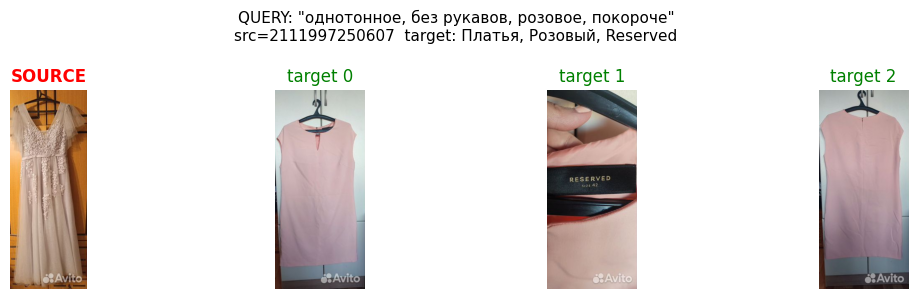

In [61]:
def show_multimodal_query_and_targets(csv_path: str, query_idx: int) -> None:
    df = pd.read_csv(csv_path)
    row = df.iloc[query_idx]

    src_path = os.path.join('dataset_1M', row['image_path'])
    target_ids = str(row['target_images_id']).split(';') if pd.notna(row['target_images_id']) else []
    target_paths = [
        os.path.join('dataset_1M', images[images['image_id'] == int(tid)]['image_path'].values[0])
        for tid in target_ids if tid
    ]

    n = 1 + len(target_paths)
    n_cols = min(4, n)
    n_rows = math.ceil(n / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
    if n_rows == 1 and n_cols == 1:
        axs = [[axs]]
    elif n_rows == 1:
        axs = [axs]
    elif n_cols == 1:
        axs = [[ax] for ax in axs]

    for i in range(n_rows * n_cols):
        r, c = divmod(i, n_cols)
        ax = axs[r][c]
        if i == 0:
            ax.imshow(Image.open(src_path))
            ax.set_title('SOURCE', color='red', fontweight='bold')
        elif i - 1 < len(target_paths):
            ax.imshow(Image.open(target_paths[i - 1]))
            ax.set_title(f'target {i - 1}', color='green')
        ax.axis('off')

    fig.suptitle(
        f'QUERY: "{row["txt_query"]}"\n'
        f'src={row["item_id"]}  target: {row["param2"]}, {row["cvet"]}, {row["brand"]}',
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()
    plt.close(fig)


show_multimodal_query_and_targets(MULTI_VAL_CSV_PATH, query_idx=19)

In [82]:
val_vis = pd.read_csv("val_dataset_vis.csv")
val_txt = pd.read_csv("val_dataset_txt.csv")
val_multimodal = pd.read_csv("val_dataset_multimodal.csv")

In [83]:
distribution_in_ds = round(items.groupby('param2').size() / len(items), 3)
distribution_in_vis = round(val_vis.groupby('param2').size() / len(val_vis), 3)
distribution_in_txt = round(val_txt.groupby('param2').size() / len(val_txt), 3)
distribution_in_mm = round(val_multimodal.groupby('param2').size() / len(val_multimodal), 3)
params = distribution_in_ds.index

In [84]:
print(params.shape)
print(distribution_in_ds.shape)
print(distribution_in_vis.shape)
print(distribution_in_txt.shape)
print(distribution_in_mm.shape)

(14,)
(14,)
(14,)
(14,)
(14,)


In [85]:
params

Index(['Брюки', 'Верхняя одежда', 'Джемперы, свитеры, кардиганы', 'Джинсы',
       'Другое', 'Купальники', 'Нижнее бельё', 'Пиджаки и костюмы', 'Платья',
       'Рубашки и блузки', 'Свадебные платья', 'Толстовки и свитшоты',
       'Топы и футболки', 'Юбки'],
      dtype='object', name='param2')

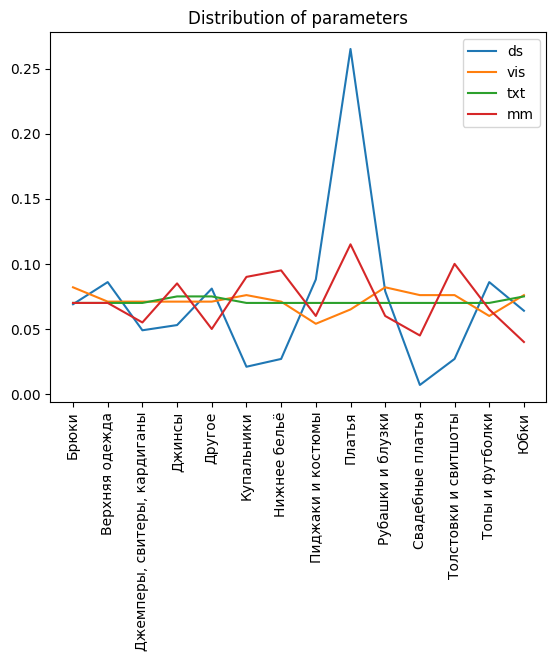

In [86]:
plt.plot(params, distribution_in_ds, label='ds')
plt.plot(params, distribution_in_vis, label='vis')
plt.plot(params, distribution_in_txt, label='txt')
plt.plot(params, distribution_in_mm, label='mm')
plt.title('Distribution of parameters')
plt.legend()
plt.xticks(ticks=range(len(params)), labels=params, rotation=90)
print()

In [87]:
val_vis.columns

Index(['query_id', 'mode', 'item_id', 'image_id', 'image_path', 'txt_query',
       'target_images_id', 'param2', 'category_name', 'sostoyanie', 'cvet',
       'brand'],
      dtype='object')

In [88]:
val_txt.columns

Index(['query_id', 'mode', 'item_id', 'image_id', 'image_path', 'txt_query',
       'target_images_id', 'param2', 'category_name', 'sostoyanie', 'cvet',
       'brand'],
      dtype='object')

In [89]:
val_multimodal.columns

Index(['query_id', 'mode', 'item_id', 'image_id', 'image_path', 'txt_query',
       'target_images_id', 'param2', 'category_name', 'sostoyanie', 'cvet',
       'brand'],
      dtype='object')

In [90]:
val_vis_new = val_vis.drop(['query_id'], axis=1)
val_txt_new = val_txt.drop(['query_id'], axis=1)
val_multimodal_new = val_multimodal.drop(['query_id'], axis=1)

val_ds = pd.concat([val_vis_new, val_txt_new, val_multimodal_new], axis=0)

In [92]:
val_ds['query_id'] = range(len(val_ds))

In [93]:
val_ds.to_csv('val_dataset.csv', index=False)